#### Foundation Model Stage

`Training loop` --> `Model Evaluation` --> `Load pre-trained weights`<br>
<br>
(`Text Generation` --> `Text Evaluation` --> `Training ang Validation losses`) --> `LLM training function`<br>
<br>
 `LLM training function` --> `Text Generation Strategies` --> `Weight saving and loading` --> `Pretrained weights from OpenAI`

In [2]:
# This safely parses the file without needing the .ipynb extension
from ipynb.fs.defs.architecture import GPTModel

import torch
print(torch.cuda.is_available())

True


In [3]:
import torch
GPT_CONFIG_124M = {
    "vocab_size" : 50257,
    "context_length": 256,
    "emb_dim": 768,
    "n_heads":12,
    "n_layers":12,
    "drop_rate":0.1,
    "qkv_bias":False
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [4]:
import tiktoken
from ipynb.fs.defs.architecture import generate_text_simple

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) #unsqueeze adds the batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) #squeeze removes the batch dimension
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)
print(f"Output text:\n {token_ids_to_text(token_ids, tokenizer)}")


Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


* model is producing gibberish because it hasn't undergone training yet

In [5]:
inputs = torch.tensor([[16833, 3626, 6100], #["every effort moves"]
                      [40, 1107, 588]])   #["I really like"]

targets = torch.tensor([[3626, 6100, 345], #["effort moves you"]
                       [1107, 588, 11311]]) #["really like chocalate"]

In [6]:
with torch.no_grad():
    logits = model(inputs)
probas = torch.softmax(logits, dim=-1)
print(probas.shape)

torch.Size([2, 3, 50257])


* `[2,3,50257]` denotes  batch of 2 sequences where each sequence has 3 tokens and each word has 50257 dimenison(each having probability for each token in the vocab), the dimension with max prob is selected as output for next time step

In [7]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print(f"Token IDs:\n {token_ids}")

Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


In [8]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)} " )

Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix 


`logits`<br>
    |<br>
    v<br>
`Probabilities`<br>
    |<br>
    v<br>
`Target Probabilities`<br>
    |<br>
    v<br>
`Average log prob`<br>
    |<br>
    v<br>
`Negative avg log prob`<br>

In [9]:
file_path = "the-verdict.txt"
with open(file_path, "r", encoding="utf-8") as file:
    text_data = file.read()

In [10]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print(f"Characters  {total_characters}")
print(f"Tokens: {total_tokens}")

Characters  20479
Tokens: 5145


In [11]:
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
test_data = text_data[split_idx:]

In [12]:
from ipynb.fs.defs.preprocessingText import create_dataloader_v1

torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size = 2,
    max_length = GPT_CONFIG_124M["context_length"],
    stride = GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    test_data,
    batch_size = 2,
    max_length = GPT_CONFIG_124M["context_length"],
    stride = GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [14]:
print("Train dataloader:")
for x,y in train_loader:
    print(x.shape, y.shape)
    
print("Validation dataloader:")
for x,y in val_loader:
    print(x.shape, y.shape)

Train dataloader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
Validation dataloader:
torch.Size([2, 256]) torch.Size([2, 256])


In [15]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1), target_batch.flatten()
    )
    return loss

In [16]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches


In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)
print(f"Training loss: {train_loss}")
print(f"Validation loss: {val_loss}")

Training loss: 10.987385114034018
Validation loss: 10.980905532836914


### Training an LLM

In [18]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1
    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            loss.backward()
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step += 1
            
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f},"
                      f"Val loss {val_loss:.3f}")
                
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )
    return train_losses, val_losses, track_tokens_seen

In [19]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
        train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
        val_loader, model, device, num_batches=eval_iter
        )
    model.train()
    return train_loss, val_loss

In [26]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))
    model.train()
    

In [32]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.004, weight_decay=0.1
    )
num_epochs = 30
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device, 
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)


Ep 1 (Step 000000): Train loss 9.458,Val loss 9.532
Ep 1 (Step 000005): Train loss 8.311,Val loss 8.822
Every effort moves you..................................................
Ep 2 (Step 000010): Train loss 7.051,Val loss 8.314
Ep 2 (Step 000015): Train loss 6.800,Val loss 8.303
Every effort moves you..................................................
Ep 3 (Step 000020): Train loss 6.663,Val loss 8.534
Ep 3 (Step 000025): Train loss 6.280,Val loss 8.346
Every effort moves you                                                  
Ep 4 (Step 000030): Train loss 6.572,Val loss 8.310
Ep 4 (Step 000035): Train loss 6.348,Val loss 8.112
Every effort moves you..................................................
Ep 5 (Step 000040): Train loss 6.358,Val loss 8.127
Every effort moves you,--,----,----------------,----------,--,------,----,------------------,--,----,--,------
Ep 6 (Step 000045): Train loss 6.120,Val loss 8.001
Ep 6 (Step 000050): Train loss 6.056,Val loss 7.921
Every effort moves you   

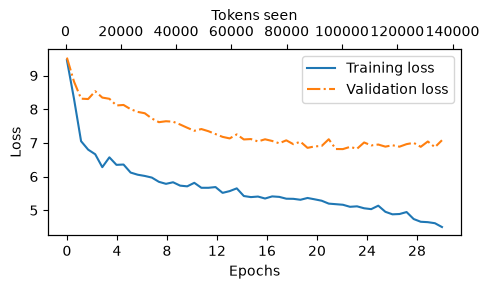

In [33]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5,3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(
        epochs_seen, val_losses, linestyle="-.", label="Validation loss"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2=ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show
    
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)    

In [34]:
torch.save(model.state_dict(), "model.pth")